# Part 2.3: Creative AI – QuickDraw ‘Pizza’ Sketch Generation

### Overview
This section explores the application of GANs in a creative setting using the QuickDraw dataset. The task focuses on generating human-like sketch drawings, which are sparse, abstract, and structurally simple compared to natural images.

### Objective
To train a Deep Convolutional GAN (DCGAN) that can learn the distribution of pizza sketches and generate realistic, diverse hand-drawn samples.

### Dataset
- Source: :contentReference[oaicite:0]{index=0}  
- Category: **Pizza**  
- Format used: **28×28 grayscale bitmap images (`.npy`)**  
- Representation: Simplified sketches rendered from vector drawings  

### Tasks Performed
- Loaded and explored the pizza sketch dataset  
- Visualised sample sketches to understand structure and variability  
- Implemented a DCGAN using convolutional layers  
- Trained the model while tracking generator and discriminator losses  
- Generated synthetic pizza sketches across training epochs  
- Compared real vs generated images visually and using metrics such as **FID**  

### Key Insight
Generating sketch data requires the model to capture global structure (e.g., circular shape, slices) rather than fine texture, making visual coherence and diversity key evaluation factors.

In [1]:
# ============================================================
# CELL 1 — IMPORTS AND GLOBAL STYLING
# ============================================================
"""
Import the libraries needed for QuickDraw Pizza loading, DCGAN training,
evaluation, and visualisation. The plotting style matches the rest of
the assignment and avoids blue shades across all saved figures.
"""

import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision.utils import make_grid

# Optional FID support
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    TORCHMETRICS_FID_AVAILABLE = True
except Exception:
    TORCHMETRICS_FID_AVAILABLE = False


# -----------------------------
# Global plotting style
# -----------------------------
COLORS = {
    "real": "#F4A261",        # warm orange
    "fake": "#E76F51",        # coral
    "loss_g": "#D81B60",      # pink
    "loss_d": "#F4B400",      # yellow-gold
    "grid": "#D9D9D9",
    "text": "#3A3A3A"
}

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["grid.color"] = COLORS["grid"]
plt.rcParams["axes.labelcolor"] = COLORS["text"]
plt.rcParams["xtick.color"] = COLORS["text"]
plt.rcParams["ytick.color"] = COLORS["text"]
plt.rcParams["text.color"] = COLORS["text"]

In [2]:
# ============================================================
# CELL 2 — CONFIGURATION AND PROJECT PATHS
# ============================================================
"""
Store the QuickDraw Pizza settings in one place and build the output
structure from the project root. Because the notebook is inside the
Notebook folder, the project root is taken as the parent directory.
"""

CONFIG_PIZZA = {
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    # Dataset
    "data_file_name": "pizza.npy",
    "image_size": 28,
    "num_channels": 1,

    # Keep runtime practical but still strong
    "max_samples": 60000,

    # Training
    "batch_size": 256,
    "z_dim": 64,
    "g_feature_maps": 48,
    "d_feature_maps": 48,
    "epochs": 30,
    "lr": 0.0002,
    "betas": (0.5, 0.999),

    # Evaluation and plotting
    "num_sample_grid": 64,
    "num_fid_samples": 1000,
    "snapshot_every": 10,
    "dpi": 300,
    "num_workers": 0
}

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name.lower() == "notebook" else NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "Data" / "DCGAN data"
OUTPUTS_ROOT = PROJECT_ROOT / "Outputs"
PART2_OUTPUT_DIR = OUTPUTS_ROOT / "Part2_outputs"
PIZZA_OUTPUT_DIR = PART2_OUTPUT_DIR / "quickdraw_pizza"
PIZZA_PLOTS_DIR = PIZZA_OUTPUT_DIR / "plots"
PIZZA_TABLES_DIR = PIZZA_OUTPUT_DIR / "tables"

PIZZA_DATA_PATH = DATA_DIR / CONFIG_PIZZA["data_file_name"]

for folder in [OUTPUTS_ROOT, PART2_OUTPUT_DIR, PIZZA_OUTPUT_DIR, PIZZA_PLOTS_DIR, PIZZA_TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

device = torch.device(CONFIG_PIZZA["device"])

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print(f"Using device               : {device}")
print(f"Notebook directory         : {NOTEBOOK_DIR}")
print(f"Project root               : {PROJECT_ROOT}")
print(f"QuickDraw pizza data path  : {PIZZA_DATA_PATH}")
print(f"QuickDraw plots folder     : {PIZZA_PLOTS_DIR}")
print(f"QuickDraw tables folder    : {PIZZA_TABLES_DIR}")
print(f"FID available              : {TORCHMETRICS_FID_AVAILABLE}")

Using device               : cpu
Notebook directory         : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Notebook
Project root               : c:\Users\girid\OneDrive\Desktop\Generative modelling case study
QuickDraw pizza data path  : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Data\DCGAN data\pizza.npy
QuickDraw plots folder     : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Outputs\Part2_outputs\quickdraw_pizza\plots
QuickDraw tables folder    : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Outputs\Part2_outputs\quickdraw_pizza\tables
FID available              : True


In [3]:
# ============================================================
# CELL 3 — REPRODUCIBILITY
# ============================================================
"""
Fix the random seed so the QuickDraw Pizza experiment is reproducible.
This makes the training behaviour, sketch outputs, and final comparisons
more stable and easier to interpret later.
"""

def set_seed(seed: int = 42) -> None:
    """
    Fix random seeds for reproducible QuickDraw Pizza training.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG_PIZZA["seed"])

In [4]:
# ============================================================
# CELL 4 — FILE PATH HELPERS
# ============================================================
"""
Create helper functions for saving QuickDraw Pizza plots and tables into
the correct folders. This keeps the notebook cleaner and makes the
outputs easier to locate during report writing.
"""

def pizza_plot_path(filename: str) -> Path:
    """
    Build the full path for a QuickDraw Pizza plot file.
    """
    return PIZZA_PLOTS_DIR / filename


def pizza_table_path(filename: str) -> Path:
    """
    Build the full path for a QuickDraw Pizza table file.
    """
    return PIZZA_TABLES_DIR / filename

In [5]:
# ============================================================
# CELL 5 — LOAD THE QUICKDRAW PIZZA BITMAPS
# ============================================================
"""
Load the QuickDraw Pizza bitmap file from the project Data folder and
inspect its structure. The bitmap file may be stored either as flattened
784-length vectors or as 28x28 images, so this cell standardises it to
a clean (N, 28, 28) format before training.
"""

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent
PIZZA_DATA_PATH = PROJECT_ROOT / "Data" / "QuickDraw" / "pizza.npy"

# Optional config (safe default)
MAX_SAMPLES = None  # set to e.g. 20000 for faster training

# ------------------------------------------------------------
# Check file exists
# ------------------------------------------------------------
print("Looking for file at:", PIZZA_DATA_PATH)

if not PIZZA_DATA_PATH.exists():
    raise FileNotFoundError(
        f"QuickDraw pizza file not found at: {PIZZA_DATA_PATH}\n"
        f"Expected location: {PROJECT_ROOT / 'Data' / 'QuickDraw' / 'pizza.npy'}"
    )

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
pizza_array = np.load(PIZZA_DATA_PATH)

if MAX_SAMPLES is not None:
    pizza_array = pizza_array[:MAX_SAMPLES]

print("\n QuickDraw Pizza loaded successfully.\n")
print("Original shape:", pizza_array.shape)
print("Data type:", pizza_array.dtype)
print("Pixel min/max:", pizza_array.min(), pizza_array.max())

# ------------------------------------------------------------
# Standardise shape to (N, 28, 28)
# ------------------------------------------------------------
if pizza_array.ndim == 2 and pizza_array.shape[1] == 784:
    pizza_array = pizza_array.reshape(-1, 28, 28)
elif pizza_array.ndim == 3 and pizza_array.shape[1:] == (28, 28):
    pass
else:
    raise ValueError(
        f"Unexpected QuickDraw Pizza shape: {pizza_array.shape}. "
        "Expected either (N, 784) or (N, 28, 28)."
    )

print("Standardised shape:", pizza_array.shape)

# ------------------------------------------------------------
# Save dataset overview
# ------------------------------------------------------------
dataset_overview = pd.DataFrame({
    "dataset": ["QuickDraw Pizza"],
    "num_images": [pizza_array.shape[0]],
    "image_height": [pizza_array.shape[1]],
    "image_width": [pizza_array.shape[2]],
    "channels": [1]
})

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

overview_path = OUTPUT_DIR / "p2_31_quickdraw_pizza_dataset_overview.csv"
dataset_overview.to_csv(overview_path, index=False)

print("\nDataset overview saved to:", overview_path)
print(dataset_overview)

Looking for file at: c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Data\QuickDraw\pizza.npy

 QuickDraw Pizza loaded successfully.

Original shape: (130371, 784)
Data type: uint8
Pixel min/max: 0 255
Standardised shape: (130371, 28, 28)

Dataset overview saved to: c:\Users\girid\OneDrive\Desktop\Generative modelling case study\outputs\tables\p2_31_quickdraw_pizza_dataset_overview.csv
           dataset  num_images  image_height  image_width  channels
0  QuickDraw Pizza      130371            28           28         1


In [6]:
# ============================================================
# CELL 6 — DATA QUALITY SNAPSHOT
# ============================================================
"""
Create a compact data quality summary for the Pizza bitmap dataset. This
gives a simple overview of image count, average pixel intensity, and the
share of active ink pixels across the sketches.
"""

active_pixel_ratio = (pizza_array > 0).mean()
mean_pixel_intensity = pizza_array.mean()
std_pixel_intensity = pizza_array.std()

pizza_quality_summary = pd.DataFrame({
    "item": [
        "num_images",
        "image_height",
        "image_width",
        "mean_pixel_intensity",
        "std_pixel_intensity",
        "active_pixel_ratio"
    ],
    "value": [
        pizza_array.shape[0],
        pizza_array.shape[1],
        pizza_array.shape[2],
        mean_pixel_intensity,
        std_pixel_intensity,
        active_pixel_ratio
    ]
})

pizza_quality_summary.to_csv(pizza_table_path("p2_32_quickdraw_pizza_quality_summary.csv"), index=False)
print(pizza_quality_summary)

                   item          value
0            num_images  130371.000000
1          image_height      28.000000
2           image_width      28.000000
3  mean_pixel_intensity      64.988207
4   std_pixel_intensity      95.829642
5    active_pixel_ratio       0.414879


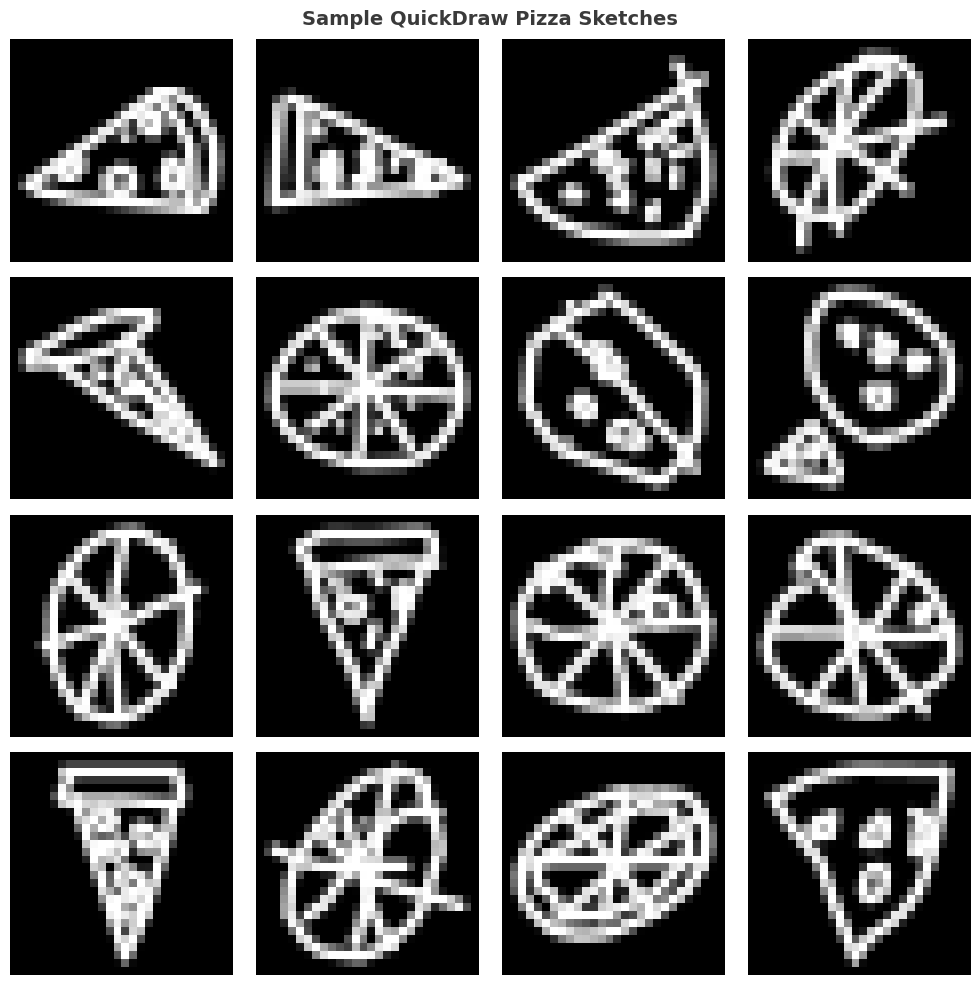

In [7]:
# ============================================================
# CELL 7 — REAL PIZZA SKETCH SAMPLE GRID
# ============================================================
"""
Display a grid of real QuickDraw Pizza sketches to understand the visual
style of the dataset. This provides the baseline view before training the
DCGAN to synthesise new pizza drawings.
"""

def show_pizza_image_grid(images: np.ndarray, n_rows: int = 4, n_cols: int = 4) -> None:
    """
    Show a grid of real QuickDraw Pizza sketches.
    """
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        ax.imshow(images[i], cmap="gray")
        ax.axis("off")

    plt.suptitle("Sample QuickDraw Pizza Sketches", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(pizza_plot_path("p2_31_quickdraw_pizza_real_sample_grid.png"), dpi=CONFIG_PIZZA["dpi"], bbox_inches="tight")
    plt.show()

show_pizza_image_grid(pizza_array, n_rows=4, n_cols=4)

In [8]:
# ============================================================
# CELL 8 — DATASET CLASS AND DATALOADER
# ============================================================
"""
Prepare a PyTorch dataset and dataloader for the QuickDraw Pizza bitmaps.
The sketches are converted to tensors, expanded to one channel, and
normalised from [0, 255] to [-1, 1] for DCGAN training.
"""

class QuickDrawPizzaDataset(torch.utils.data.Dataset):
    """
    Create a PyTorch dataset for QuickDraw Pizza bitmap images.
    """
    def __init__(self, images: np.ndarray):
        images = images.astype(np.float32) / 255.0
        images = np.expand_dims(images, axis=1)   # (N, 1, 28, 28)
        images = (images - 0.5) / 0.5             # scale to [-1, 1]
        self.images = torch.tensor(images, dtype=torch.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx]


pizza_dataset = QuickDrawPizzaDataset(pizza_array)
pin_memory_flag = torch.cuda.is_available()

pizza_loader = DataLoader(
    pizza_dataset,
    batch_size=CONFIG_PIZZA["batch_size"],
    shuffle=True,
    num_workers=CONFIG_PIZZA["num_workers"],
    pin_memory=pin_memory_flag,
    drop_last=False
)

sample_batch = next(iter(pizza_loader))
print("Pizza batch shape:", sample_batch.shape)

Pizza batch shape: torch.Size([256, 1, 28, 28])


In [9]:
# ============================================================
# CELL 9 — DCGAN MODEL DEFINITIONS
# ============================================================
"""
Define the generator and discriminator for the QuickDraw Pizza DCGAN.
Because the data consists of 28x28 grayscale sketches, a lightweight
convolutional architecture is used to keep training efficient.
"""

class PizzaGenerator(nn.Module):
    """
    Build the DCGAN generator for 28x28 grayscale pizza sketches.
    """
    def __init__(self, z_dim=64, feature_maps=48, img_channels=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, feature_maps * 4, 7, 1, 0, bias=False),   # -> 7x7
            nn.BatchNorm2d(feature_maps * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1, bias=False),  # -> 14x14
            nn.BatchNorm2d(feature_maps * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_maps * 2, img_channels, 4, 2, 1, bias=False),      # -> 28x28
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class PizzaDiscriminator(nn.Module):
    """
    Build the DCGAN discriminator for 28x28 grayscale pizza sketches.
    """
    def __init__(self, feature_maps=48, img_channels=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, feature_maps, 4, 2, 1, bias=False),          # -> 14x14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1, bias=False),      # -> 7x7
            nn.BatchNorm2d(feature_maps * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_maps * 2, 1, 7, 1, 0, bias=False),                  # -> 1x1
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


def weights_init(module):
    """
    Apply standard DCGAN-style weight initialisation.
    """
    classname = module.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0)

In [10]:
# ============================================================
# CELL 10 — TRAINING AND VISUALISATION HELPERS
# ============================================================
"""
Create helper functions for image denormalisation, latent sampling, loss
plotting, and saved sketch grids. These keep the training code simpler
and make the outputs easier to reuse in the report.
"""

def denormalise_images(x: torch.Tensor) -> torch.Tensor:
    """
    Convert images from [-1, 1] back to [0, 1] for display and saving.
    """
    return (x + 1) / 2


def sample_latent(batch_size: int, z_dim: int, device: torch.device) -> torch.Tensor:
    """
    Sample latent noise vectors for the generator.
    """
    return torch.randn(batch_size, z_dim, 1, 1, device=device)


def save_generated_grid(
    generator: nn.Module,
    fixed_noise: torch.Tensor,
    filename: str,
    title: str = None,
    show_plot: bool = True
) -> None:
    """
    Save a grid of generated QuickDraw Pizza sketches from fixed latent noise.
    """
    generator.eval()
    with torch.no_grad():
        fake_images = generator(fixed_noise).cpu()

    grid = make_grid(denormalise_images(fake_images), nrow=8, padding=2)

    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)).squeeze(), cmap="gray")
    if title is not None:
        plt.title(title, fontsize=13, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(pizza_plot_path(filename), dpi=CONFIG_PIZZA["dpi"], bbox_inches="tight")
    if show_plot:
        plt.show()
    else:
        plt.close()


def save_real_batch_grid(dataloader: DataLoader, filename: str) -> None:
    """
    Save and display a grid of real preprocessed QuickDraw Pizza sketches.
    """
    real_batch = next(iter(dataloader))
    grid = make_grid(denormalise_images(real_batch[:64]), nrow=8, padding=2)

    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)).squeeze(), cmap="gray")
    plt.title("Real QuickDraw Pizza Sketches", fontsize=13, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(pizza_plot_path(filename), dpi=CONFIG_PIZZA["dpi"], bbox_inches="tight")
    plt.show()


def save_loss_plot(g_losses: list, d_losses: list, filename: str) -> None:
    """
    Save and display the QuickDraw Pizza generator and discriminator loss curves.
    """
    plt.figure(figsize=(8, 4))
    plt.plot(g_losses, color=COLORS["loss_g"], linewidth=2.2, label="Generator Loss")
    plt.plot(d_losses, color=COLORS["loss_d"], linewidth=2.2, label="Discriminator Loss")
    plt.title("QuickDraw Pizza DCGAN Loss Curves", fontsize=13, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(pizza_plot_path(filename), dpi=CONFIG_PIZZA["dpi"], bbox_inches="tight")
    plt.show()

In [11]:
# ============================================================
# CELL 11 — INITIALISE MODELS, OPTIMISERS, AND FIXED NOISE
# ============================================================
"""
Initialise the QuickDraw Pizza DCGAN, apply weight initialisation, and
prepare the optimisers and fixed latent vectors. The fixed noise is reused
across epochs so generator progress can be compared consistently.
"""

generator = PizzaGenerator(
    z_dim=CONFIG_PIZZA["z_dim"],
    feature_maps=CONFIG_PIZZA["g_feature_maps"],
    img_channels=CONFIG_PIZZA["num_channels"]
).to(device)

discriminator = PizzaDiscriminator(
    feature_maps=CONFIG_PIZZA["d_feature_maps"],
    img_channels=CONFIG_PIZZA["num_channels"]
).to(device)

generator.apply(weights_init)
discriminator.apply(weights_init)

criterion = nn.BCELoss()

optimizer_g = optim.Adam(generator.parameters(), lr=CONFIG_PIZZA["lr"], betas=CONFIG_PIZZA["betas"])
optimizer_d = optim.Adam(discriminator.parameters(), lr=CONFIG_PIZZA["lr"], betas=CONFIG_PIZZA["betas"])

fixed_noise = sample_latent(CONFIG_PIZZA["num_sample_grid"], CONFIG_PIZZA["z_dim"], device)

g_losses = []
d_losses = []

In [12]:
# ============================================================
# CELL 12 — DCGAN TRAINING LOOP
# ============================================================
"""
Train the QuickDraw Pizza DCGAN and record the generator and discriminator
losses over time. To keep the notebook faster, training snapshots are
saved during training but only the final key plots are displayed later.
"""

for epoch in range(CONFIG_PIZZA["epochs"]):
    generator.train()
    discriminator.train()

    g_epoch_loss = 0.0
    d_epoch_loss = 0.0

    for real_images in pizza_loader:
        real_images = real_images.to(device, non_blocking=True)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # -------------------------
        # Train discriminator
        # -------------------------
        discriminator.zero_grad(set_to_none=True)

        real_output = discriminator(real_images)
        d_loss_real = criterion(real_output, real_labels)

        z = sample_latent(batch_size, CONFIG_PIZZA["z_dim"], device)
        fake_images = generator(z)
        fake_output = discriminator(fake_images.detach())
        d_loss_fake = criterion(fake_output, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_d.step()

        # -------------------------
        # Train generator
        # -------------------------
        generator.zero_grad(set_to_none=True)

        z = sample_latent(batch_size, CONFIG_PIZZA["z_dim"], device)
        fake_images = generator(z)
        fake_output = discriminator(fake_images)

        g_loss = criterion(fake_output, real_labels)
        g_loss.backward()
        optimizer_g.step()

        g_epoch_loss += g_loss.item()
        d_epoch_loss += d_loss.item()

    g_losses.append(g_epoch_loss / len(pizza_loader))
    d_losses.append(d_epoch_loss / len(pizza_loader))

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1:>2}/{CONFIG_PIZZA['epochs']}] "
            f"| D Loss: {d_losses[-1]:.4f} "
            f"| G Loss: {g_losses[-1]:.4f}"
        )

    if (epoch + 1) % CONFIG_PIZZA["snapshot_every"] == 0 or (epoch + 1) == CONFIG_PIZZA["epochs"]:
        save_generated_grid(
            generator=generator,
            fixed_noise=fixed_noise,
            filename=f"p2_32_quickdraw_pizza_generated_grid_epoch_{epoch+1:02d}.png",
            title=f"Generated QuickDraw Pizza Sketches — Epoch {epoch+1}",
            show_plot=False
        )

training_history_pizza = pd.DataFrame({
    "epoch": np.arange(1, CONFIG_PIZZA["epochs"] + 1),
    "generator_loss": g_losses,
    "discriminator_loss": d_losses
})
training_history_pizza.to_csv(pizza_table_path("p2_33_quickdraw_pizza_training_history.csv"), index=False)

print("QuickDraw Pizza training complete.")

Epoch [ 1/30] | D Loss: 0.8012 | G Loss: 1.4276
Epoch [ 5/30] | D Loss: 0.3133 | G Loss: 2.6587
Epoch [10/30] | D Loss: 0.3298 | G Loss: 2.5671
Epoch [15/30] | D Loss: 0.2811 | G Loss: 2.7848
Epoch [20/30] | D Loss: 0.2521 | G Loss: 3.1651
Epoch [25/30] | D Loss: 0.2113 | G Loss: 3.4847
Epoch [30/30] | D Loss: 0.4569 | G Loss: 3.4015
QuickDraw Pizza training complete.


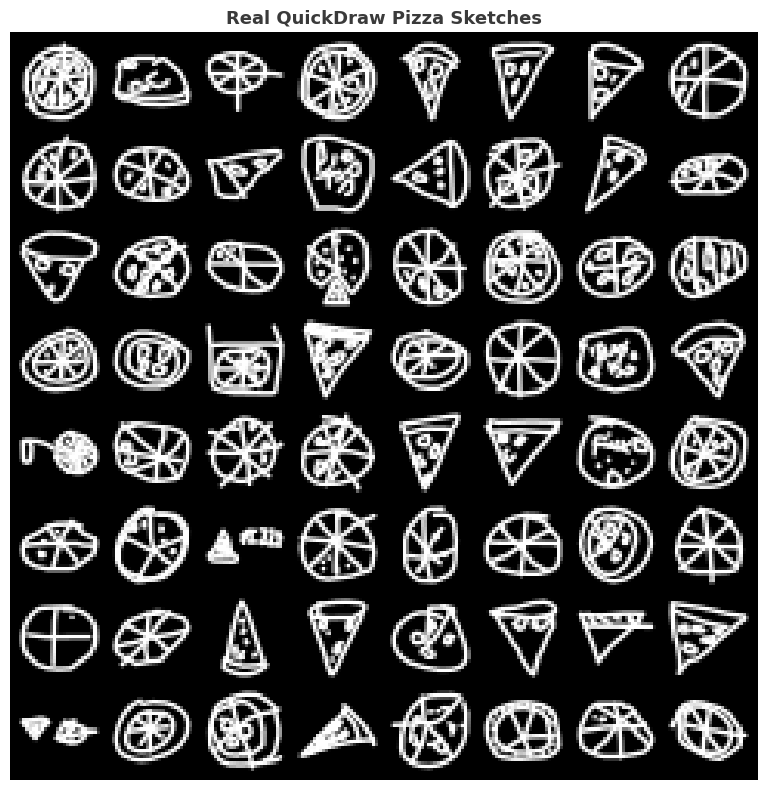

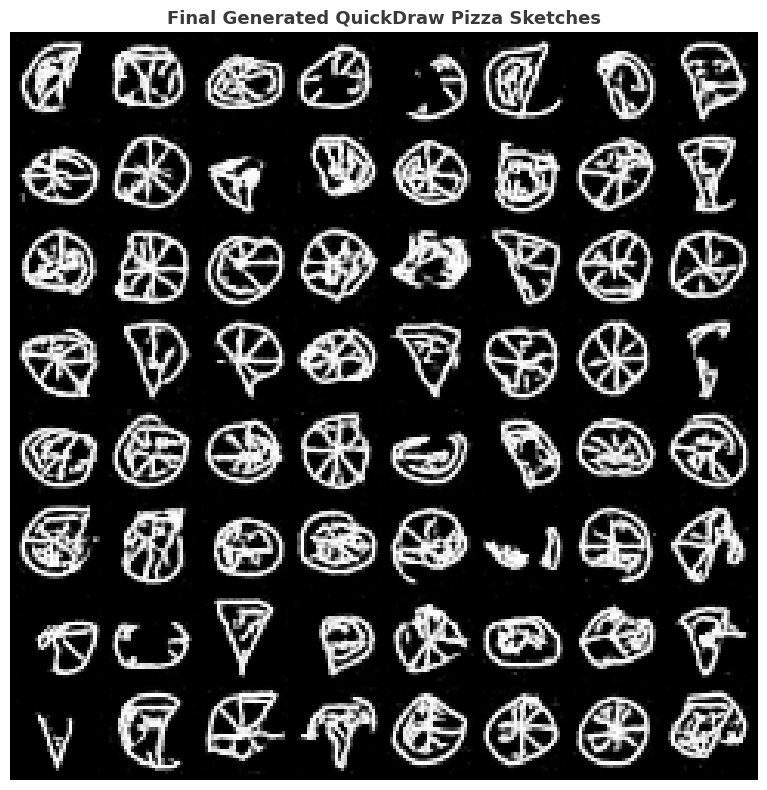

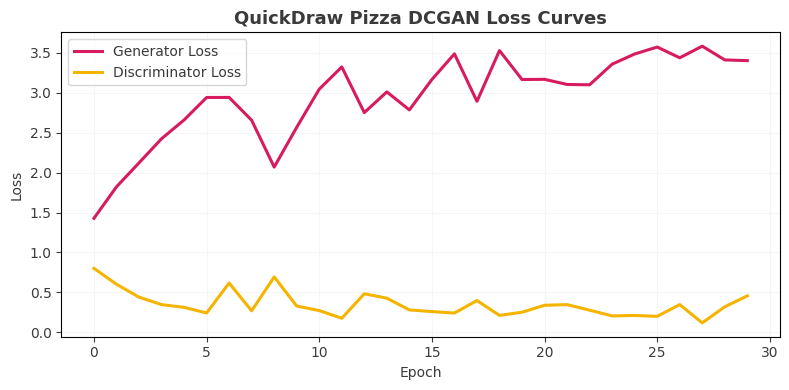

In [13]:
# ============================================================
# CELL 13 — SAVE AND DISPLAY THE MAIN FINAL PLOTS
# ============================================================
"""
Save and display the main final QuickDraw Pizza outputs. This includes the
real sketch grid, final generated sketch grid, and loss curves that are
most useful for the report and final evaluation.
"""

save_real_batch_grid(pizza_loader, "p2_33_quickdraw_pizza_real_image_grid.png")

save_generated_grid(
    generator=generator,
    fixed_noise=fixed_noise,
    filename="p2_34_quickdraw_pizza_final_generated_image_grid.png",
    title="Final Generated QuickDraw Pizza Sketches",
    show_plot=True
)

save_loss_plot(
    g_losses=g_losses,
    d_losses=d_losses,
    filename="p2_35_quickdraw_pizza_loss_curves.png"
)

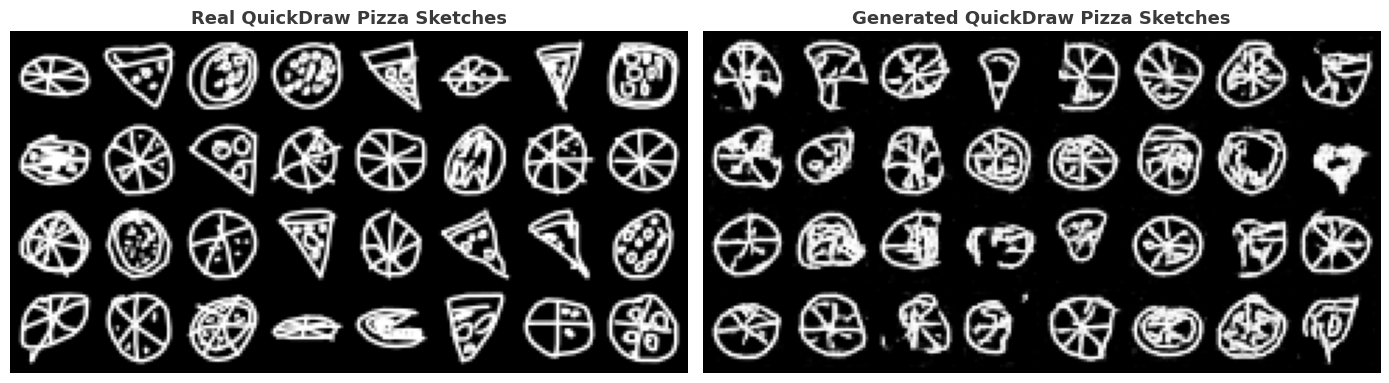

In [14]:
# ============================================================
# CELL 14 — REAL VS GENERATED SIDE-BY-SIDE COMPARISON
# ============================================================
"""
Create a side-by-side comparison between real and generated QuickDraw
Pizza sketches. This is one of the clearest figures to include in the
report because it directly shows sketch quality and recognisability.
"""

real_batch = next(iter(pizza_loader))
real_vis = denormalise_images(real_batch[:32]).cpu()

generator.eval()
with torch.no_grad():
    fake_vis = denormalise_images(
        generator(sample_latent(32, CONFIG_PIZZA["z_dim"], device))
    ).cpu()

real_grid = make_grid(real_vis, nrow=8, padding=2)
fake_grid = make_grid(fake_vis, nrow=8, padding=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor("white")

axes[0].imshow(np.transpose(real_grid.numpy(), (1, 2, 0)).squeeze(), cmap="gray")
axes[0].set_title("Real QuickDraw Pizza Sketches", fontsize=13, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(np.transpose(fake_grid.numpy(), (1, 2, 0)).squeeze(), cmap="gray")
axes[1].set_title("Generated QuickDraw Pizza Sketches", fontsize=13, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(pizza_plot_path("p2_36_quickdraw_pizza_real_vs_generated_comparison.png"), dpi=CONFIG_PIZZA["dpi"], bbox_inches="tight")
plt.show()

In [15]:
# ============================================================
# CELL 15 — FID EVALUATION
# ============================================================
"""
Compute an FID score to compare real and generated QuickDraw Pizza
sketches in feature space. Grayscale images are repeated across channels
so they can be evaluated with the standard image-based FID pipeline.
"""

fid_results = []

if TORCHMETRICS_FID_AVAILABLE:
    try:
        fid_metric = FrechetInceptionDistance(feature=2048).to(device)

        num_fid = CONFIG_PIZZA["num_fid_samples"]

        # ----------------------------------------------------
        # Collect real images
        # ----------------------------------------------------
        real_images_for_fid = []
        total_real = 0

        for images in pizza_loader:
            real_images_for_fid.append(images)
            total_real += images.size(0)
            if total_real >= num_fid:
                break

        real_images_for_fid = torch.cat(real_images_for_fid, dim=0)[:num_fid]

        # ----------------------------------------------------
        # Generate fake images
        # ----------------------------------------------------
        fake_images_for_fid = []
        generator.eval()

        with torch.no_grad():
            remaining = num_fid
            while remaining > 0:
                current_batch = min(CONFIG_PIZZA["batch_size"], remaining)
                z = sample_latent(current_batch, CONFIG_PIZZA["z_dim"], device)
                fake_batch = generator(z).cpu()
                fake_images_for_fid.append(fake_batch)
                remaining -= current_batch

        fake_images_for_fid = torch.cat(fake_images_for_fid, dim=0)[:num_fid]

        # ----------------------------------------------------
        # Convert grayscale 1-channel to 3-channel for FID
        # ----------------------------------------------------
        real_rgb = denormalise_images(real_images_for_fid).repeat(1, 3, 1, 1)
        fake_rgb = denormalise_images(fake_images_for_fid).repeat(1, 3, 1, 1)

        real_uint8 = real_rgb.mul(255).clamp(0, 255).to(torch.uint8).to(device)
        fake_uint8 = fake_rgb.mul(255).clamp(0, 255).to(torch.uint8).to(device)

        fid_metric.update(real_uint8, real=True)
        fid_metric.update(fake_uint8, real=False)
        fid_score = float(fid_metric.compute().item())

        fid_results.append({
            "metric": "FID",
            "value": fid_score,
            "num_real_images": num_fid,
            "num_fake_images": num_fid,
            "status": "computed_successfully"
        })

        print(f"QuickDraw Pizza FID: {fid_score:.4f}")

    except Exception as e:
        print("FID computation failed:", str(e))
        fid_results.append({
            "metric": "FID",
            "value": np.nan,
            "num_real_images": 0,
            "num_fake_images": 0,
            "status": f"failed: {str(e)}"
        })
else:
    print("torchmetrics FID is not available in this environment.")
    fid_results.append({
        "metric": "FID",
        "value": np.nan,
        "num_real_images": 0,
        "num_fake_images": 0,
        "status": "torchmetrics_fid_not_available"
    })

fid_results_df = pd.DataFrame(fid_results)
fid_results_df.to_csv(pizza_table_path("p2_34_quickdraw_pizza_fid_results.csv"), index=False)
print(fid_results_df)

QuickDraw Pizza FID: 41.7457
  metric      value  num_real_images  num_fake_images                 status
0    FID  41.745682             1000             1000  computed_successfully


In [16]:
# ============================================================
# CELL 16 — COMPACT EXPERIMENT SUMMARY TABLE
# ============================================================
"""
Create one compact summary table with the final QuickDraw Pizza settings
and main results. This gives a clean numerical record of the experiment
without overcrowding the report with too many separate tables.
"""

final_fid_value = (
    fid_results_df["value"].iloc[0]
    if "value" in fid_results_df.columns else np.nan
)

final_fid_status = (
    fid_results_df["status"].iloc[0]
    if "status" in fid_results_df.columns else "unknown"
)

pizza_summary = pd.DataFrame({
    "item": [
        "num_images_used",
        "image_height",
        "image_width",
        "epochs",
        "batch_size",
        "latent_dim",
        "final_generator_loss",
        "final_discriminator_loss",
        "fid_value",
        "fid_status",
        "device_used"
    ],
    "value": [
        pizza_array.shape[0],
        pizza_array.shape[1],
        pizza_array.shape[2],
        CONFIG_PIZZA["epochs"],
        CONFIG_PIZZA["batch_size"],
        CONFIG_PIZZA["z_dim"],
        g_losses[-1],
        d_losses[-1],
        final_fid_value,
        final_fid_status,
        str(device)
    ]
})

pizza_summary.to_csv(pizza_table_path("p2_35_quickdraw_pizza_experiment_summary.csv"), index=False)
print(pizza_summary)

                        item                  value
0            num_images_used                 130371
1               image_height                     28
2                image_width                     28
3                     epochs                     30
4                 batch_size                    256
5                 latent_dim                     64
6       final_generator_loss               3.401488
7   final_discriminator_loss               0.456893
8                  fid_value              41.745682
9                 fid_status  computed_successfully
10               device_used                    cpu
